# West Coast Wildfire Risk Assessment: Random Forest Modeling

Dataset Shape: (39616, 26)

First few rows:
   Unnamed: 0                    FIRE FIRE_NUM     START_DATE  END_DATE  \
0           0             RAIL CANYON  UNKNOWN  8/1/1994 0:00  8/1/1994   
1           1              CORK SCREW  UNKNOWN  8/1/1994 0:00  8/1/1994   
2           2                OWENS RD  UNKNOWN  8/1/1994 0:00  8/1/1994   
3           3  NEWKIRK - OLD TRAIL RD  UNKNOWN  1/1/1997 0:00  1/1/1997   
4           4               RIVERSIDE  UNKNOWN  8/1/1994 0:00  8/1/1994   

        ACRES  YEAR   FIRE_LAT   FiRE_LONG STATE  ...  TMIN_F TMEAN_F  TMAX_F  \
0  102.096839  1994  47.921707 -117.657560    WA  ...    54.5    72.5    90.4   
1  185.872679  1994  47.842525 -117.770714    WA  ...    54.5    72.5    90.4   
2  127.004055  1994  47.922992 -117.416886    WA  ...    54.5    72.5    90.4   
3  772.418058  1997  47.705981 -117.515694    WA  ...    36.6    42.7    48.8   
4  455.865724  1994  47.712254 -117.498282    WA  ...    54.5    72.5    90.4   

   TDMEAN_F  VPDMI

<Figure size 800x600 with 0 Axes>

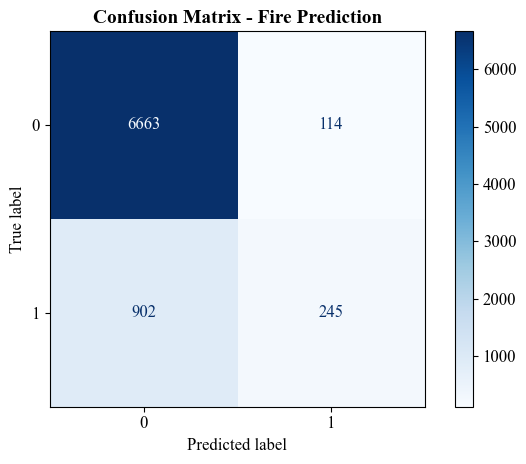

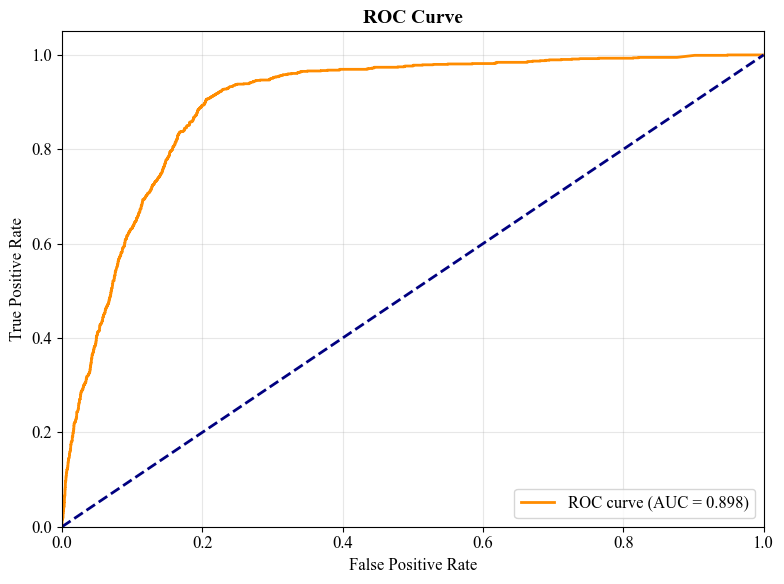

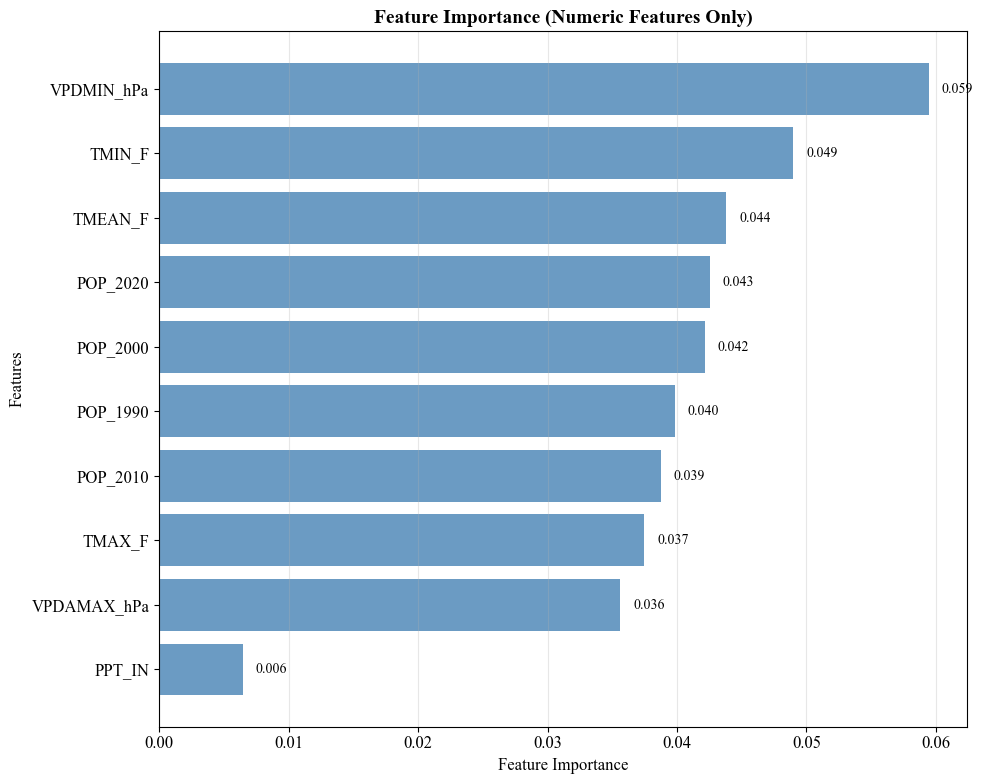

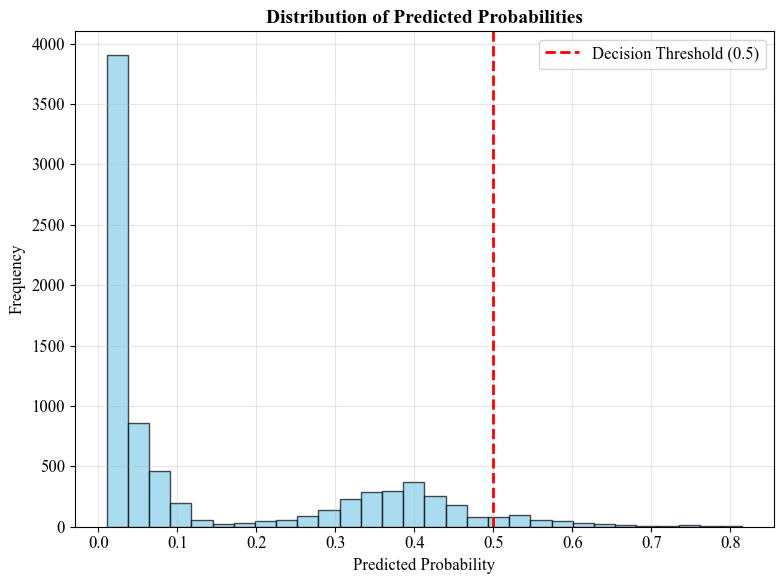


All plots saved as PNG files:
- confusion_matrix.png
- roc_curve.png
- feature_importance.png
- prediction_distribution.png

Top 5 Most Important Numeric Features:
1. VPDMIN_hPa: 0.0594
2. TMIN_F: 0.0490
3. TMEAN_F: 0.0438
4. POP_2020: 0.0425
5. POP_2000: 0.0421

Detailed Performance Metrics:
Precision: 0.6825
Recall: 0.2136
F1-Score: 0.3254

Sample predictions:
       actual  predicted  probability
31285       0          0     0.443477
16941       0          0     0.076189
37146       0          0     0.303664
18417       0          0     0.014095
830         1          1     0.676259
3358        0          0     0.018018
10391       0          0     0.013766
138         1          1     0.579310
16214       0          0     0.016425
39094       0          0     0.312662


In [15]:
#Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#Loading merged dataset
data = pd.read_csv(r"C:\Users\Melis\Downloads\Final-Analysis-Dataset-Project-1.csv")

print("Dataset Shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

#Defining binary target: 1 if fire > 100 acres, else 0
data['fire_occurred'] = (data['ACRES'] > 100).astype(int)

print(f"\nTarget Distribution:")
print(f"Fires > 100 acres: {data['fire_occurred'].sum()} ({data['fire_occurred'].mean():.2%})")
print(f"Fires <= 100 acres: {(data['fire_occurred'] == 0).sum()} ({(data['fire_occurred'] == 0).mean():.2%})")

#Features to use in feature vector
features = [
    'TMIN_F', 'TMEAN_F', 'TMAX_F', 'PPT_IN',
    'VPDMIN_hPa', 'VPDAMAX_hPa',
    'POP_1990', 'POP_2000', 'POP_2010', 'POP_2020',
    'STATE', 'WEATHER_STATION'
]

X = data[features]
y = data['fire_occurred']

#Checking for missing values
print(f"\nMissing values per feature:")
missing_vals = X.isnull().sum()
print(missing_vals[missing_vals > 0])

#Identify numerical and categorical features in feature vector
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = ['STATE', 'WEATHER_STATION']

print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

#Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ])

#Full pipeline with Random Forest
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10))
])

#Training model
print("\nTraining model...")
pipeline.fit(X_train, y_train)

#Predictions
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

#Model Evaluation
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)

#Accuracy and AUC
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc_score:.4f}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

#Visualizations
# Set font to Times New Roman for all plots
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# 1. Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix - Fire Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Feature Importance (for numeric features only)
rf_model = pipeline.named_steps['classifier']
feature_names = numeric_features  # Only numeric features for simplicity

#Getting feature importances for numeric features only
preprocessor_fitted = pipeline.named_steps['preprocess']
n_numeric_features = len(numeric_features)
numeric_importances = rf_model.feature_importances_[:n_numeric_features]

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': numeric_importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], 
                color='steelblue', alpha=0.8)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance (Numeric Features Only)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

#Adding value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Prediction Distribution
plt.figure(figsize=(8, 6))
plt.hist(y_pred_proba, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll plots saved as PNG files:")
print("- confusion_matrix.png")
print("- roc_curve.png") 
print("- feature_importance.png")
print("- prediction_distribution.png")

# Additional Analysis: Top Features
print(f"\nTop 5 Most Important Numeric Features:")
for i, (feat, imp) in enumerate(feature_importance_df.tail().values[::-1], 1):
    print(f"{i}. {feat}: {imp:.4f}")

# Model Performance by Class
print(f"\nDetailed Performance Metrics:")
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Save predictions for further analysis
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'probability': y_pred_proba
})

print(f"\nSample predictions:")
print(results_df.head(10))